In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

from src.model import GConv2D, GMaxPooling

tf.random.set_seed(42)
np.random.seed(42)

plt.style.use("src/hep.mplstyle")

## Data Preparation

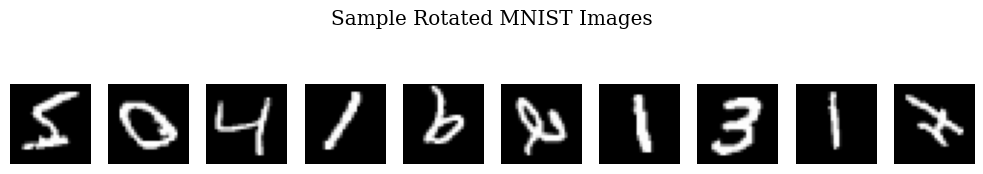

In [29]:
def random_rot90(image):
    """Function to randomly rotate images by a multiple of 90 degrees"""
    # image shape: (28,28) or (28,28,1)
    k = np.random.randint(0, 4)  # choose 0, 1, 2 or 3
    return np.rot90(image, k)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Expand dims to have channel axis and normalise to [0,1]
x_train = np.expand_dims(x_train, axis=-1).astype('float32') / 255.0
x_test  = np.expand_dims(x_test, axis=-1).astype('float32') / 255.0

# Apply random 90-degree rotations to the training and test sets.
x_train_rot = np.array([random_rot90(img) for img in x_train])
x_test_rot  = np.array([random_rot90(img) for img in x_test])
# Plot some sample rotated MNIST images
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train_rot[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Sample Rotated MNIST Images")
plt.show()

### Effect Visualisation

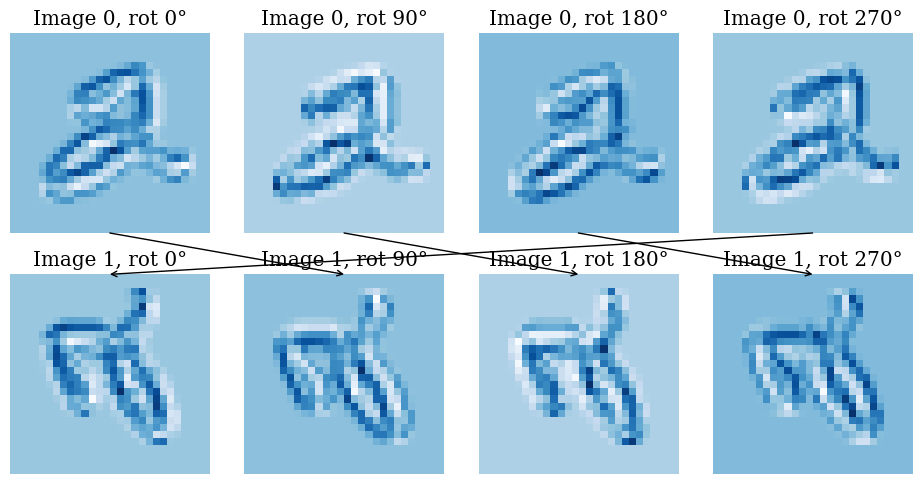

In [30]:
# Rotate a MNIST image by 90 degrees (CCW)
image = x_train[5] # shape = (28, 28, 1)
rotated_image = tf.image.rot90(image, k=1)
batch = tf.stack([image, rotated_image], axis=0)

# Apply gconv
gconv = GConv2D(filters=2, kernel_size=3, padding='SAME')
_ = gconv(tf.zeros_like(batch))  # initialisation
output = gconv(batch)  # shape = (2, 28, 28, 8)

# Visualise the four rotated outputs
from matplotlib.patches import ConnectionPatch

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i in range(2):
    for j in range(4):
        ch_index = j * 2
        axes[i, j].imshow(output[i, :, :, ch_index], cmap='Blues')
        axes[i, j].set_title(f"Image {i}, rot {j*90}°")
        axes[i, j].axis('off')

# Add arrows
for j in range(4):
    # centre of the top row
    con = ConnectionPatch(
        xyA=(0.5, 0), coordsA=axes[0, j].transAxes,
        # centre of the bottom row
        xyB=(0.5, 1), coordsB=axes[1, (j + 1) % 4].transAxes,
        arrowstyle="->", color="black", lw=1
    )
    fig.add_artist(con)

plt.savefig('figures/equivariance_visual_with_arrows.pdf')
plt.show()


## Model Comparison

**FCC Model**

In [31]:
def build_fc_model():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

fc_model = build_fc_model()
fc_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

**G-CNN Model**

In [32]:
def build_gcnn_model():
    inputs = layers.Input(shape=(28,28,1))
    # Apply the custom group conv layer (GConv2D)
    x = GConv2D(filters=8, kernel_size=3, strides=1, padding='SAME')(inputs)
    x = layers.ReLU()(x)
    # Using group pooling can get rotation invariant features:
    x = GMaxPooling()(x)  # Output shape becomes (batch, 28, 28, filters)
    
    # Add a second standard convolution layer
    x = layers.Conv2D(16, kernel_size=3, activation='relu', padding='SAME')(x)
    x = layers.MaxPooling2D(pool_size=(2,2))(x)
    
    # Flatten and add fully-connected layers
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

gcnn_model = build_gcnn_model()
gcnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ g_conv2d_23 (GConv2D)           │ (None, 28, 28, 32)     │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ g_max_pooling_1 (GMaxPooling)   │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,690 (791.76 KB)

 Trainable params: 202,690 (791.76 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
print("Training Fully Connected Model...")
history_fc = fc_model.fit(x_train_rot, y_train, epochs=50, batch_size=1024,
                          validation_data=(x_test_rot, y_test))

print("\nTraining G-CNN Model...")
history_gcnn = gcnn_model.fit(x_train_rot, y_train, epochs=50, batch_size=1024,
                              validation_data=(x_test_rot, y_test))

# Takes 10 minutes on my MacBook, the implementation details can be better optimised

Training Fully Connected Model...
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4660 - loss: 1.6322 - val_accuracy: 0.7858 - val_loss: 0.7326
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8080 - loss: 0.6632 - val_accuracy: 0.8667 - val_loss: 0.4655
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8764 - loss: 0.4329 - val_accuracy: 0.8974 - val_loss: 0.3503
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9091 - loss: 0.3188 - val_accuracy: 0.9104 - val_loss: 0.2977
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9264 - loss: 0.2556 - val_accuracy: 0.9200 - val_loss: 0.2675
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9391 - loss: 0.2139 - val_accuracy: 0.9247 - val_loss: 0.2473
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9490 - loss: 0.1832 - val_accuracy: 0.9310 - val_loss: 0.2333
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9556 - loss: 0.1594 

W0000 00:00:1744289639.728106 3597752 loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/functional_3_1/g_conv2d_23_1/rot90_12/Assert/AssertGuard/branch_executed/_271


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4419 - loss: 1.7047

W0000 00:00:1744289651.386119 3597752 loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/functional_3_1/g_conv2d_23_1/rot90_29/Assert/AssertGuard/branch_executed/_576


59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.4444 - loss: 1.6976 - val_accuracy: 0.7532 - val_loss: 0.7597
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.7987 - loss: 0.6674 - val_accuracy: 0.8485 - val_loss: 0.4908
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.8672 - loss: 0.4520 - val_accuracy: 0.8836 - val_loss: 0.3765
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.8949 - loss: 0.3551 - val_accuracy: 0.9103 - val_loss: 0.3023
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - accuracy: 0.9149 - loss: 0.2898 - val_accuracy: 0.9224 - val_loss: 0.2644
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.9260 - loss: 0.2491 - val_accuracy: 0.9305 - val_loss: 0.2364
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.9349 - loss: 0.2189 - val_accuracy: 0.9346 - val_loss: 0.2145
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.9416 - loss: 0.1955 - val_accuracy: 0.940

### Training Curves

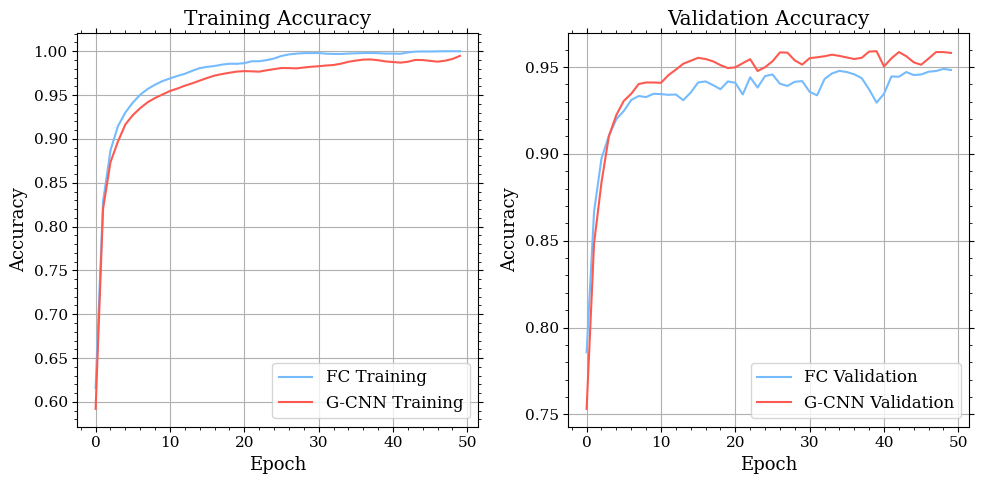

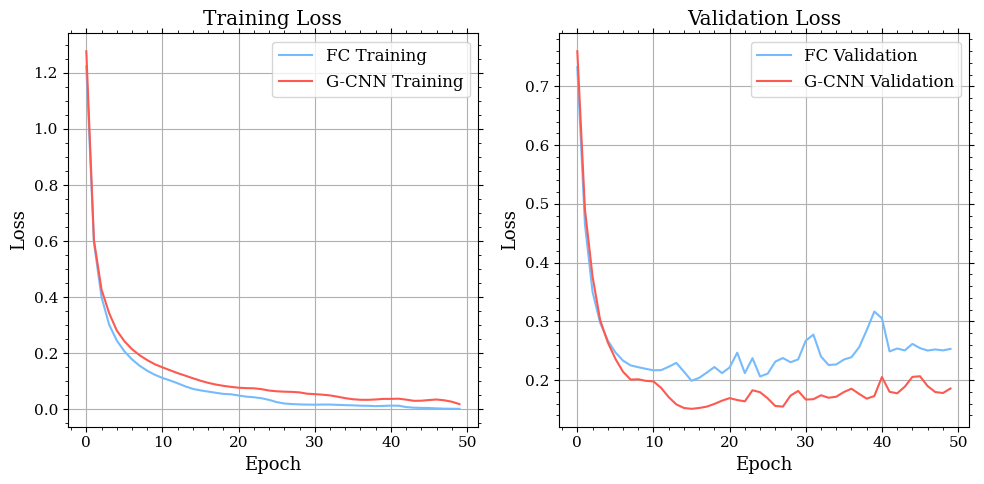

In [34]:
# Plot accuracy curves
plt.figure(figsize=(10, 5))

# Training accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fc.history['accuracy'], label='FC Training')
plt.plot(history_gcnn.history['accuracy'], label='G-CNN Training')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_fc.history['val_accuracy'], label='FC Validation')
plt.plot(history_gcnn.history['val_accuracy'], label='G-CNN Validation')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('figures/accuracy_comparison.pdf', dpi=300)
plt.show()

# Plot loss curves
plt.figure(figsize=(10, 5))

# Training loss
plt.subplot(1, 2, 1)
plt.plot(history_fc.history['loss'], label='FC Training')
plt.plot(history_gcnn.history['loss'], label='G-CNN Training')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation loss
plt.subplot(1, 2, 2)
plt.plot(history_fc.history['val_loss'], label='FC Validation')
plt.plot(history_gcnn.history['val_loss'], label='G-CNN Validation')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('figures/loss_comparison.pdf', dpi=300)
plt.show()